In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt 
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve

# Set seaborn style for better looking graphs
sns.set_theme(style="whitegrid")

In [ ]:
# Load data & model
print("Loading data...")
X_test = np.load("../data/processed/X_test.npy")
y_test = np.load("../data/processed/y_test.npy", allow_pickle=True)

print("Loading model...")
autoencoder = load_model("autoencoder.keras")

print(f"Test data shape: {X_test.shape}")
print("Ready for evaluation.")

Loading data...
Loading model...
Test data shape: (1012266, 21)
Ready for evaluation.


In [3]:
print("Running Prediction & Calculating Reconstruction Errors...")

# 1. Predict using batch_size to prevent memory crash
reconstructions = autoencoder.predict(X_test, batch_size=4096, verbose=1)

# 2. Calculate MSE (Threat Scores)
mse = np.mean(np.power(X_test - reconstructions, 2), axis=1)

# 3. Create Binary Labels for Evaluation ('BENIGN' = 0, 'Attack' = 1)
y_test_binary = np.array([0 if str(label).strip().upper() == 'BENIGN' else 1 for label in y_test])

print(f"\nCalculated {len(mse)} threat scores.")
print(f"Average Error: {np.mean(mse):.4f}")
print(f"Min Error: {np.min(mse):.4f}")
print(f"Max Error: {np.max(mse):.4f}")

Running Prediction & Calculating Reconstruction Errors...
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step

Calculated 1012266 threat scores.
Average Error: 0.4391
Min Error: 0.0000
Max Error: 165.3438


In [4]:
print("Calculating Optimal Threshold via PR-Curve...")

# 1. Mathematically Find the Optimal Threshold
precisions, recalls, thresholds = precision_recall_curve(y_test_binary, mse)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

print(f"---> Found Optimal Threshold: {optimal_threshold:.6f}")

# 2. Classify using the optimal threshold
y_pred = [1 if e > optimal_threshold else 0 for e in mse]

# 3. Final Metrics
accuracy = accuracy_score(y_test_binary, y_pred)
f1 = f1_score(y_test_binary, y_pred)
precision = precision_score(y_test_binary, y_pred)
recall = recall_score(y_test_binary, y_pred)

print(f"\n--- Centralized Model Performance (Optimized) ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

Calculating Optimal Threshold via PR-Curve...
---> Found Optimal Threshold: 0.001201

--- Centralized Model Performance (Optimized) ---
Accuracy:  0.7796
F1 Score:  0.8195
Precision: 0.7465
Recall:    0.9083


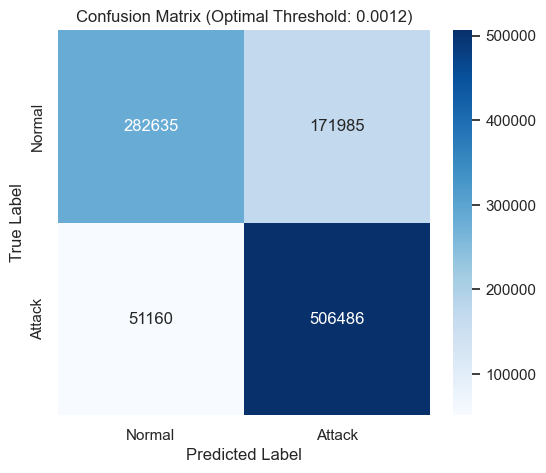

In [5]:
# Confusion Matrix
cm = confusion_matrix(y_test_binary, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title(f"Confusion Matrix (Optimal Threshold: {optimal_threshold:.4f})")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

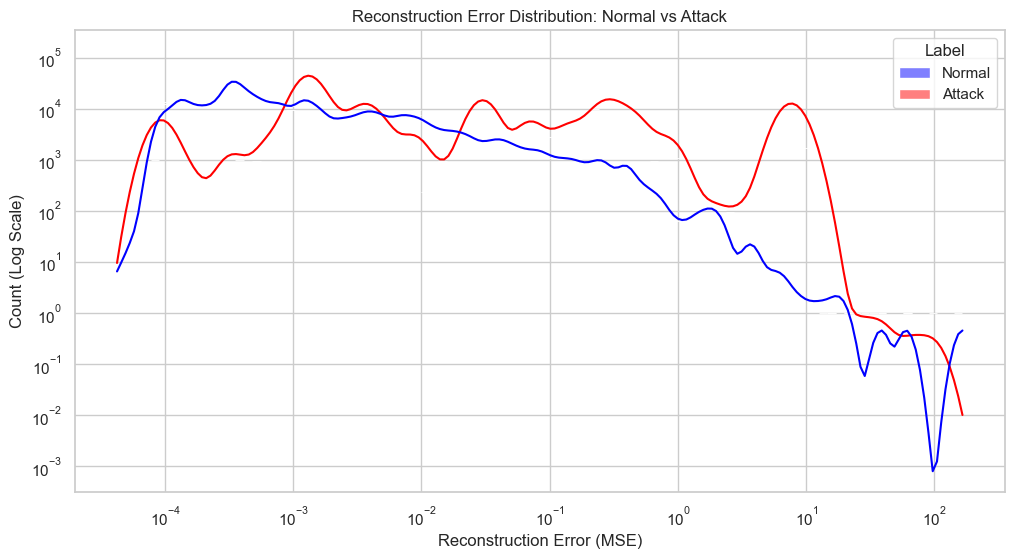

In [6]:
# Error Distribution Visualization
error_df = pd.DataFrame({
    'reconstruction_error': mse, 
    'true_class': y_test_binary
})

# Map binary back to text for the legend
error_df['Label'] = error_df['true_class'].apply(lambda x: 'Normal' if x == 0 else 'Attack')

plt.figure(figsize=(12,6))
sns.histplot(
    data=error_df,
    x='reconstruction_error',
    hue='Label',
    bins=100,
    kde=True,
    palette={'Normal': 'blue', 'Attack': 'red'},
    log_scale=(True, True)
)  

plt.title("Reconstruction Error Distribution: Normal vs Attack")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Count (Log Scale)")
plt.show()

/Users/sujannainawasti/miniconda3/envs/fl_project/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


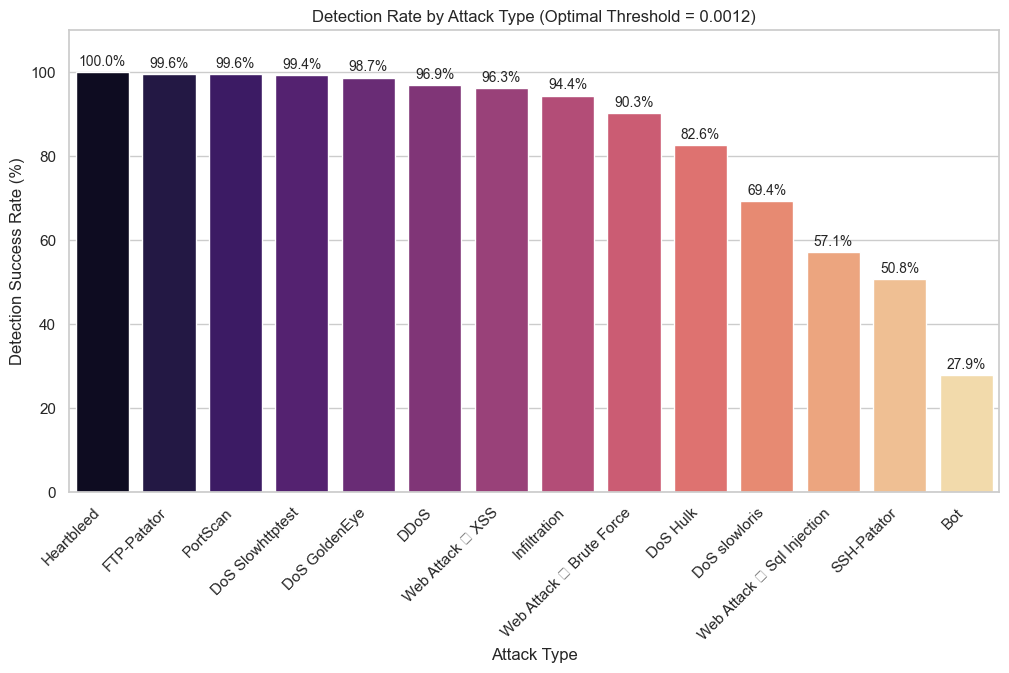

In [7]:
# Attack detection breakdown by specific attack types
raw_labels = [str(label).strip() for label in y_test]

breakdown_df = pd.DataFrame({
    'Attack_Type': raw_labels,
    'Predicted_Status': ['Detected' if p == 1 else 'Missed' for p in y_pred]
})

# Taking only the attacks (ignoring BENIGN)
attack_df = breakdown_df[breakdown_df['Attack_Type'] != 'BENIGN']

# Calculate detection rate per attack type
detection_stats = attack_df.groupby('Attack_Type')['Predicted_Status'].value_counts(normalize=True).unstack().fillna(0)

if "Detected" not in detection_stats.columns:
    detection_stats['Detected'] = 0.0

detection_rates = detection_stats['Detected'] * 100
detection_rates = detection_rates.sort_values(ascending=False)

# Visualize Breakdown
plt.figure(figsize=(12, 6))
sns.barplot(x=detection_rates.index, y=detection_rates.values, hue=detection_rates.index, palette='magma', legend=False)

# Dynamic Title showing the actual threshold used
plt.title(f"Detection Rate by Attack Type (Optimal Threshold = {optimal_threshold:.4f})")
plt.ylabel("Detection Success Rate (%)")
plt.xlabel("Attack Type")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 110) # Set to 110 to give room for the text labels

# Add percentage text above bars
for i, v in enumerate(detection_rates.values):
    plt.text(i, v + 1.5, f"{v:.1f}%", ha='center', fontsize=10)

plt.show()